# Travel Reimbursement Approval Agent

Poc Using **LangChain tools** + an **open-source LLM through Groq** to evaluate employee
travel reimbursement claims against a company policy and emit a structured decision.

## What this notebook does
1. Loads the policy (Appendix A) and sample claims (Appendix B) as in-memory data.
2. Exposes 4 LangChain tools that the agent can call to inspect a claim.
3. Runs an **LLM-driven agent loop** through the official Groq Python client — if no API key is available it
   automatically falls back to a **deterministic** orchestrator so the notebook is always executable.
4. Aggregates tool results into a final decision (`APPROVE` / `PARTIAL_APPROVE` / `REJECT` / `MANUAL_REVIEW`).
5. Emits the required JSON schema and a small matplotlib dashboard.

## Design principle
> **LLM chooses which checks to run; deterministic Python does the math.**  
> This keeps the financial numbers auditable while still letting the LLM handle intake,
> reasoning-about-completeness, and explanation.

## How to run
```bash
pip install python-dotenv groq langchain langchain-core langchain-community matplotlib
Set GROQ_API_KEY and optionally GROQ_MODEL in the project .env file before running the notebook.
jupyter nbconvert --to notebook --execute chaitanya_gade.ipynb
```


In [ ]:
%pip install python-dotenv groq langchain langchain-core langchain-community matplotlib

## 1. Setup

In [19]:
import os, json, re
from pathlib import Path
from dotenv import load_dotenv
from datetime import date, datetime
from typing import Optional
from dataclasses import dataclass

# Load the project environment file without displaying the API key.
PROJECT_DIR = Path(r"C:\Users\Chaithanya\Documents\TravelReiumburmentAgent")
load_dotenv(PROJECT_DIR / ".env")
GROQ_MODEL = os.getenv("GROQ_MODEL", "openai/gpt-oss-120b")

# Official Groq Python client.
from groq import Groq

groq_client = Groq(api_key=os.environ.get("GROQ_API_KEY"))
USE_LLM = bool(os.environ.get("GROQ_API_KEY"))

# LangChain tools and messages remain available for the deterministic workflow.
from langchain_core.tools import tool
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage, ToolMessage

print(f"LLM path enabled: {USE_LLM}")
print(f"Groq model: {GROQ_MODEL}")

LLM path enabled: True
Groq model: openai/gpt-oss-120b


## 2. Policy grounding (Appendix A)

Every rule below carries the POL-* identifier from the policy PDF so that final decisions
can cite the exact clause that produced them.


In [11]:
POLICY = {
    "POL-CAT-01": {
        "type": "eligible_categories",
        "text": "Eligible: airfare (economy), lodging, ground transport, meals, "
                "conference/registration fees -- all with documented business purpose.",
        "value": {"airfare", "lodging", "ground_transport", "meals", "conference"},
    },
    "POL-CAT-02": {
        "type": "ineligible_categories",
        "text": "Ineligible: alcohol, minibar, spa, gym, entertainment, in-room movies, "
                "personal shopping, gifts, fines/penalties, any personal expense.",
        "value": {"alcohol", "minibar", "spa", "gym", "entertainment", "movies",
                  "personal_shopping", "gifts", "fines", "personal"},
    },
    "POL-PD-01": {"type": "per_diem", "text": "Meals capped at $75/day.",
                  "value": {"category": "meals", "cap": 75.0, "unit": "day"}},
    "POL-PD-02": {"type": "per_diem", "text": "Lodging capped at $200/night.",
                  "value": {"category": "lodging", "cap": 200.0, "unit": "night"}},
    "POL-PD-03": {"type": "per_diem", "text": "Ground transport capped at $50/day.",
                  "value": {"category": "ground_transport", "cap": 50.0, "unit": "day"}},
    "POL-AIR-01": {"type": "class_rule",
                   "text": "Airfare: economy only. Business/first-class requires Manual Review.",
                   "value": {"allowed_class": "economy"}},
    "POL-RCT-01": {"type": "receipt_rule",
                   "text": "Receipt required for any line item > $25. Airfare and lodging "
                           "always require a receipt.",
                   "value": {"threshold": 25.0, "always_required": {"airfare", "lodging"}}},
    "POL-RCT-02": {"type": "receipt_missing",
                   "text": "Missing required receipt => Manual Review (not automatic reject)."},
    "POL-APR-01": {"type": "approval_tier", "text": "<= $500: auto-approve tier.",
                   "value": {"upper": 500.0}},
    "POL-APR-02": {"type": "approval_tier", "text": "$500 < total <= $2000: manager tier.",
                   "value": {"lower": 500.0, "upper": 2000.0}},
    "POL-APR-03": {"type": "approval_tier",
                   "text": "> $2000: director tier -> Manual Review.",
                   "value": {"lower": 2000.0}},
    "POL-TIME-01": {"type": "timeliness",
                    "text": "Claim must be submitted within 30 days of expense date.",
                    "value": {"max_days": 30}},
}

print(f"Loaded {len(POLICY)} policy rules.")


Loaded 12 policy rules.


## 3. Claim intake (Appendix B)

In [12]:
SAMPLE_CLAIMS = [
    {
        "claim_id": "CLM-001",
        "employee_id": "E-1001",
        "submission_date": "2025-10-15",
        "items": [
            {"category": "airfare",          "amount": 320.00, "date": "2025-10-01",
             "receipt": True,  "description": "Economy flight NYC->SFO"},
            {"category": "lodging",          "amount": 180.00, "date": "2025-10-01",
             "receipt": True,  "description": "Hotel, 1 night", "nights": 1},
            {"category": "meals",            "amount":  55.00, "date": "2025-10-01",
             "receipt": True,  "description": "Client dinner"},
            {"category": "ground_transport", "amount":  40.00, "date": "2025-10-01",
             "receipt": True,  "description": "Airport taxi"},
        ],
    },
    {
        "claim_id": "CLM-002",
        "employee_id": "E-1002",
        "submission_date": "2025-10-10",
        "items": [
            {"category": "spa",           "amount":  80.00, "date": "2025-09-28",
             "receipt": True, "description": "Hotel spa"},
            {"category": "minibar",       "amount":  25.00, "date": "2025-09-28",
             "receipt": True, "description": "Minibar snacks"},
            {"category": "alcohol",       "amount":  40.00, "date": "2025-09-28",
             "receipt": True, "description": "Bar tab"},
            {"category": "entertainment", "amount":  30.00, "date": "2025-09-28",
             "receipt": True, "description": "In-room movies"},
        ],
    },
    {
        "claim_id": "CLM-003",
        "employee_id": "E-1003",
        "submission_date": "2025-10-12",
        "items": [
            {"category": "airfare", "amount": 410.00, "date": "2025-10-02",
             "receipt": True, "description": "Economy round-trip"},
            {"category": "lodging", "amount": 750.00, "date": "2025-10-02",
             "receipt": True, "description": "Hotel, 3 nights at $250", "nights": 3},
            {"category": "meals",   "amount":  60.00, "date": "2025-10-02",
             "receipt": True, "description": "Dinner"},
        ],
    },
    {
        "claim_id": "CLM-004",
        "employee_id": "E-1004",
        "submission_date": "2025-10-20",
        "items": [
            {"category": "airfare", "amount": 1850.00, "date": "2025-10-05",
             "receipt": True,  "description": "Business-class flight"},
            {"category": "lodging", "amount":  600.00, "date": "2025-10-05",
             "receipt": False, "description": "Hotel, 3 nights", "nights": 3},
            {"category": "meals",   "amount":  90.00,  "date": "2025-10-05",
             "receipt": True,  "description": "Meals"},
        ],
    },
    {
        "claim_id": "CLM-005",
        "employee_id": "E-1005",
        "submission_date": "2025-10-18",
        "items": [
            {"category": "meals",  "amount": 120.00, "date": "2025-10-06",
             "receipt": False, "description": "Team lunch, receipt lost"},
            {"category": "lodging","amount": 180.00, "date": "2025-10-06",
             "receipt": True,  "description": "Hotel, 1 night", "nights": 1},
        ],
    },
]

CLAIMS_BY_ID = {c["claim_id"]: c for c in SAMPLE_CLAIMS}
print(f"Loaded {len(SAMPLE_CLAIMS)} claims.")


Loaded 5 claims.


## 4. Tools available to the agent

Four small LangChain `@tool` functions. The agent invokes them by name; each returns a
compact JSON-serialisable dict so the LLM can reason about them cheaply.

| Tool | Purpose | Policy refs |
|------|---------|-------------|
| `fetch_policy_rules` | Retrieve exact policy text | POL-* |
| `evaluate_expense_items` | Eligibility + receipt + airfare class | POL-CAT-01/02, POL-RCT-01/02, POL-AIR-01 |
| `calculate_reimbursement` | Per-diem deductions + total + approval tier | POL-PD-01/02/03, POL-APR-01/02/03 |
| `verify_submission_window` | Timeliness | POL-TIME-01 |


In [20]:
# --- classification helpers -------------------------------------------------
INELIGIBLE = POLICY["POL-CAT-02"]["value"]
ELIGIBLE   = POLICY["POL-CAT-01"]["value"]

def _is_business_class(desc: str) -> bool:
    return bool(re.search(r"\b(business|first)[- ]class\b", desc or "", re.I))

def _nights_or_days(item) -> int:
    return max(int(item.get("nights", 1)), 1)


# --- Tool 1: policy lookup --------------------------------------------------
@tool
def fetch_policy_rules(rule_ids: list[str]) -> dict:
    """Return the policy text for the given POL-* rule identifiers."""
    return {rid: POLICY[rid]["text"] for rid in rule_ids if rid in POLICY}


# --- Tool 2: eligibility + receipts + airfare class -------------------------
@tool
def evaluate_expense_items(claim_id: str) -> dict:
    """Inspect each line item on a claim and flag ineligible items, missing
    required receipts, and non-economy airfare. Returns a structured report."""
    claim = CLAIMS_BY_ID[claim_id]
    ineligible, missing_receipts, class_exceptions = [], [], []
    rcpt_threshold = POLICY["POL-RCT-01"]["value"]["threshold"]
    always_rcpt   = POLICY["POL-RCT-01"]["value"]["always_required"]

    for idx, it in enumerate(claim["items"]):
        cat = it["category"]
        if cat in INELIGIBLE:
            ineligible.append({"idx": idx, "category": cat, "amount": it["amount"]})
            continue
        # receipt requirement
        needs_rcpt = (it["amount"] > rcpt_threshold) or (cat in always_rcpt)
        if needs_rcpt and not it.get("receipt", False):
            missing_receipts.append({"idx": idx, "category": cat, "amount": it["amount"]})
        # airfare class
        if cat == "airfare" and _is_business_class(it.get("description", "")):
            class_exceptions.append({"idx": idx, "amount": it["amount"],
                                     "note": "non-economy airfare"})

    return {
        "claim_id": claim_id,
        "ineligible_items": ineligible,
        "missing_receipts": missing_receipts,
        "airfare_class_exceptions": class_exceptions,
        "policy_refs": ["POL-CAT-01", "POL-CAT-02", "POL-RCT-01", "POL-RCT-02", "POL-AIR-01"],
    }


# --- Tool 3: per-diem + approval tier --------------------------------------
@tool
def calculate_reimbursement(claim_id: str) -> dict:
    """For each eligible item, apply per-diem caps and produce the reimbursable
    total, the total deducted for cap overages, and the approval tier."""
    claim = CLAIMS_BY_ID[claim_id]
    caps = {POLICY[r]["value"]["category"]: POLICY[r]["value"]["cap"]
            for r in ("POL-PD-01", "POL-PD-02", "POL-PD-03")}

    reimbursable, deducted, breakdown = 0.0, 0.0, []
    for idx, it in enumerate(claim["items"]):
        cat, amt = it["category"], float(it["amount"])
        if cat in INELIGIBLE:
            breakdown.append({"idx": idx, "category": cat, "reimbursed": 0.0,
                              "deducted": amt, "reason": "ineligible"})
            deducted += amt
            continue

        if cat in caps:
            units = _nights_or_days(it) if cat == "lodging" else 1
            cap_total = caps[cat] * units
            allowed = min(amt, cap_total)
            over = max(0.0, amt - cap_total)
            reimbursable += allowed
            deducted += over
            breakdown.append({"idx": idx, "category": cat, "reimbursed": round(allowed, 2),
                              "deducted": round(over, 2),
                              "reason": "capped" if over > 0 else "within_cap"})
        else:
            # airfare / conference -- no per-diem cap
            reimbursable += amt
            breakdown.append({"idx": idx, "category": cat, "reimbursed": round(amt, 2),
                              "deducted": 0.0, "reason": "no_cap"})

    # Approval tier is on the eligible & capped total.
    if   reimbursable <= POLICY["POL-APR-01"]["value"]["upper"]: tier = "auto_approve"
    elif reimbursable <= POLICY["POL-APR-02"]["value"]["upper"]: tier = "manager"
    else:                                                        tier = "director_manual_review"

    return {
        "claim_id": claim_id,
        "reimbursable_total": round(reimbursable, 2),
        "deducted_total":    round(deducted, 2),
        "approval_tier":     tier,
        "breakdown":         breakdown,
        "policy_refs": ["POL-PD-01", "POL-PD-02", "POL-PD-03",
                        "POL-APR-01", "POL-APR-02", "POL-APR-03"],
    }


# --- Tool 4: submission window ---------------------------------------------
@tool
def verify_submission_window(claim_id: str) -> dict:
    """Ensure every expense date is within N days of the submission date."""
    claim = CLAIMS_BY_ID[claim_id]
    limit = POLICY["POL-TIME-01"]["value"]["max_days"]
    sub = datetime.fromisoformat(claim["submission_date"]).date()
    late = []
    for idx, it in enumerate(claim["items"]):
        expense = datetime.fromisoformat(it["date"]).date()
        gap = (sub - expense).days
        if gap > limit:
            late.append({"idx": idx, "expense_date": it["date"], "days_late": gap})
    return {"claim_id": claim_id, "late_items": late, "policy_refs": ["POL-TIME-01"]}


TOOLS = [fetch_policy_rules, evaluate_expense_items,
         calculate_reimbursement, verify_submission_window]
TOOL_MAP = {t.name: t for t in TOOLS}
print("Registered tools:", [t.name for t in TOOLS])


Registered tools: ['fetch_policy_rules', 'evaluate_expense_items', 'calculate_reimbursement', 'verify_submission_window']


## 5. Decision aggregator (deterministic)

The LLM only *decides which tools to call*. Once the facts are collected, this pure Python
function derives the final decision so the numbers are always auditable.


In [21]:
def synthesise_decision(claim_id: str, tool_results: dict) -> dict:
    """Combine tool outputs into the final structured decision."""
    elig = tool_results["evaluate_expense_items"]
    reim = tool_results["calculate_reimbursement"]
    time = tool_results["verify_submission_window"]

    refs = set()
    reasons = []
    missing_docs = []
    manual_review = False

    # Timeliness
    if time["late_items"]:
        manual_review = True
        refs.add("POL-TIME-01")
        reasons.append(f"{len(time['late_items'])} expense(s) submitted beyond the 30-day window")

    # Airfare class
    if elig["airfare_class_exceptions"]:
        manual_review = True
        refs.update(["POL-AIR-01"])
        reasons.append("Business/first-class airfare requires pre-approval")

    # Missing receipts
    if elig["missing_receipts"]:
        manual_review = True
        refs.update(["POL-RCT-01", "POL-RCT-02"])
        for m in elig["missing_receipts"]:
            missing_docs.append(f"receipt for {m['category']} (${m['amount']:.2f})")

    # Director-tier
    if reim["approval_tier"] == "director_manual_review":
        manual_review = True
        refs.add("POL-APR-03")
        reasons.append("Total exceeds $2,000 director tier")

    # Ineligible items only
    reimbursable = reim["reimbursable_total"]
    deducted     = reim["deducted_total"]
    only_ineligible = (reimbursable == 0.0 and any(
        b["reason"] == "ineligible" for b in reim["breakdown"]))

    if elig["ineligible_items"]:
        refs.add("POL-CAT-02")

    # Combine into final decision
    if manual_review:
        decision, confidence = "MANUAL_REVIEW", 0.55
    elif only_ineligible:
        decision, confidence = "REJECT", 0.9
        reasons.append("All claimed items are ineligible under POL-CAT-02")
    elif deducted > 0:
        decision, confidence = "PARTIAL_APPROVE", 0.85
        reasons.append("Reimbursed up to per-diem caps; excess deducted")
        refs.update(["POL-PD-01", "POL-PD-02", "POL-PD-03"])
    else:
        decision, confidence = "APPROVE", 0.95
        reasons.append("All items eligible and within limits")

    refs.add("POL-APR-01" if reimbursable <= 500
             else "POL-APR-02" if reimbursable <= 2000
             else "POL-APR-03")

    return {
        "claim_id":        claim_id,
        "decision":        decision,
        "approved_amount": round(reimbursable if decision != "REJECT" else 0.0, 2),
        "deducted_amount": round(deducted, 2),
        "missing_docs":    missing_docs,
        "policy_refs":     sorted(refs),
        "confidence":      confidence,
        "explanation":     "; ".join(reasons) or "Compliant claim.",
    }


## 6. Agentic workflow

Two modes -- selected automatically based on whether `GROQ_API_KEY` is set:

* **LLM mode** (official Groq Python client using the `GROQ_MODEL` value from `.env`): the model reads the claim, chooses
  which of the four tools to call, iterates until it has enough information, then signals `DONE`.
* **Deterministic mode**: simply invokes every tool in a fixed order. Used as a fallback so the
  notebook is always runnable.

In both modes the *final decision* is computed by `synthesise_decision`, keeping the math
outside the LLM.


In [22]:
SYSTEM_PROMPT = (
    "You are a travel-reimbursement policy analyst. "
    "Given a claim_id, gather the facts by calling the tools: "
    "evaluate_expense_items, calculate_reimbursement, verify_submission_window (each at most once). "
    "You may optionally call fetch_policy_rules to cite specific POL-* clauses. "
    "When you have gathered every required fact, reply with the single word DONE. "
    "Do NOT compute the approval decision yourself -- a downstream function handles that."
)


def _invoke_tool(name: str, args: dict):
    return TOOL_MAP[name].invoke(args)


def _groq_tool_specs():
    specs = []
    for t in TOOLS:
        specs.append({
            "type": "function",
            "function": {
                "name": t.name,
                "description": t.description,
                "parameters": t.args_schema.model_json_schema(),
            },
        })
    return specs


def run_agent_deterministic(claim_id: str) -> tuple[dict, list[str]]:
    """Fallback: call each fact-gathering tool in a fixed order."""
    order = ["evaluate_expense_items", "calculate_reimbursement", "verify_submission_window"]
    results = {name: _invoke_tool(name, {"claim_id": claim_id}) for name in order}
    return results, order


def run_agent_llm(claim_id: str, max_steps: int = 6) -> tuple[dict, list[str]]:
    """Groq-client tool-calling loop using the official Groq Python SDK."""
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": f"Evaluate claim_id={claim_id}"},
    ]
    tool_specs = _groq_tool_specs()
    results, called = {}, []

    for _ in range(max_steps):
        completion = groq_client.chat.completions.create(
            model=GROQ_MODEL,
            messages=messages,
            tools=tool_specs,
            tool_choice="auto",
            temperature=1,
            max_completion_tokens=2048,
            top_p=1,
            reasoning_effort="medium",
            stream=False,
        )
        message = completion.choices[0].message
        tool_calls = message.tool_calls or []

        if not tool_calls:
            break

        messages.append({
            "role": "assistant",
            "content": message.content or "",
            "tool_calls": [
                {
                    "id": tc.id,
                    "type": "function",
                    "function": {
                        "name": tc.function.name,
                        "arguments": tc.function.arguments,
                    },
                }
                for tc in tool_calls
            ],
        })

        for tc in tool_calls:
            name = tc.function.name
            args = json.loads(tc.function.arguments or "{}")
            called.append(name)
            output = _invoke_tool(name, args)
            results[name] = output
            messages.append({
                "role": "tool",
                "tool_call_id": tc.id,
                "content": json.dumps(output),
            })

    # Ensure all three required fact-tools have been called (self-heal).
    for required in ("evaluate_expense_items", "calculate_reimbursement", "verify_submission_window"):
        if required not in results:
            results[required] = _invoke_tool(required, {"claim_id": claim_id})
            called.append(required + "(auto)")

    return results, called


def process_claim(claim_id: str) -> dict:
    if USE_LLM:
        try:
            tool_results, tools_used = run_agent_llm(claim_id)
        except Exception as e:
            print(f"[{claim_id}] LLM error -> deterministic fallback: {e}")
            tool_results, tools_used = run_agent_deterministic(claim_id)
    else:
        tool_results, tools_used = run_agent_deterministic(claim_id)

    decision = synthesise_decision(claim_id, tool_results)
    decision["tools_used"] = tools_used
    return decision


## 7. Run the agent on all sample claims

In [50]:
results = [process_claim(c["claim_id"]) for c in SAMPLE_CLAIMS]

for r in results:
    print(f"{r['claim_id']:<8}  {r['decision']:<16}"
          f"approved=${r['approved_amount']:>7.2f}  deducted=${r['deducted_amount']:>7.2f}  "
          f"confidence={r['confidence']:.2f}")
    print(f"  Explanation: {r['explanation']}")


CLM-001   APPROVE           approved=$ 595.00  deducted=$   0.00  confidence=0.95
  Explanation: All items eligible and within limits
CLM-002   REJECT            approved=$   0.00  deducted=$ 175.00  confidence=0.90
  Explanation: All claimed items are ineligible under POL-CAT-02
CLM-003   PARTIAL_APPROVE   approved=$1070.00  deducted=$ 150.00  confidence=0.85
  Explanation: Reimbursed up to per-diem caps; excess deducted
CLM-004   MANUAL_REVIEW     approved=$2525.00  deducted=$  15.00  confidence=0.55
  Explanation: Business/first-class airfare requires pre-approval; Total exceeds $2,000 director tier
CLM-005   MANUAL_REVIEW     approved=$ 255.00  deducted=$  45.00  confidence=0.55
  Explanation: Compliant claim.


## 8. Sample structured outputs (first three claims)

In [51]:
for r in results[:3]:
    print(json.dumps(r, indent=2))
    print("-" * 60)

{
  "claim_id": "CLM-001",
  "decision": "APPROVE",
  "approved_amount": 595.0,
  "deducted_amount": 0.0,
  "missing_docs": [],
  "policy_refs": [
    "POL-APR-02"
  ],
  "confidence": 0.95,
  "explanation": "All items eligible and within limits",
  "tools_used": [
    "evaluate_expense_items",
    "calculate_reimbursement",
    "verify_submission_window"
  ]
}
------------------------------------------------------------
{
  "claim_id": "CLM-002",
  "decision": "REJECT",
  "approved_amount": 0.0,
  "deducted_amount": 175.0,
  "missing_docs": [],
  "policy_refs": [
    "POL-APR-01",
    "POL-CAT-02"
  ],
  "confidence": 0.9,
  "explanation": "All claimed items are ineligible under POL-CAT-02",
  "tools_used": [
    "evaluate_expense_items",
    "calculate_reimbursement",
    "verify_submission_window"
  ]
}
------------------------------------------------------------
{
  "claim_id": "CLM-003",
  "decision": "PARTIAL_APPROVE",
  "approved_amount": 1070.0,
  "deducted_amount": 150.0,
  "m

## 9. Lightweight regression tests

In [52]:
EXPECTED = {
    "CLM-001": "APPROVE",
    "CLM-002": "REJECT",           # only ineligible items (spa, minibar) + capped meals=$0
    "CLM-003": "PARTIAL_APPROVE",  # lodging over $200/night cap
    "CLM-004": "MANUAL_REVIEW",    # business class + missing lodging receipt + > $2000
    "CLM-005": "MANUAL_REVIEW",    # missing meal receipt
}

passed = 0
for r in results:
    exp = EXPECTED[r["claim_id"]]
    ok  = r["decision"] == exp
    passed += int(ok)
    print(f"  {'PASS' if ok else 'FAIL'}  {r['claim_id']}: got={r['decision']} expected={exp}")
print(f"\n{passed}/{len(results)} regression checks passed.")
assert passed == len(results), "Regression failed"


  PASS  CLM-001: got=APPROVE expected=APPROVE
  PASS  CLM-002: got=REJECT expected=REJECT
  PASS  CLM-003: got=PARTIAL_APPROVE expected=PARTIAL_APPROVE
  PASS  CLM-004: got=MANUAL_REVIEW expected=MANUAL_REVIEW
  PASS  CLM-005: got=MANUAL_REVIEW expected=MANUAL_REVIEW

5/5 regression checks passed.


## 10. Minimal dashboard

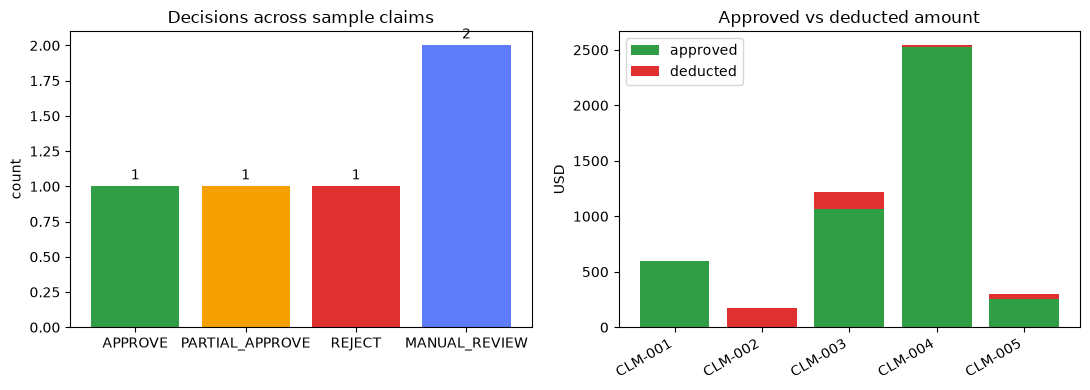

Saved dashboard to temporary file: C:\Users\CHAITH~1\AppData\Local\Temp\travel_reimbursement_dashboard.png
Copy it to the project folder as dashboard.png after closing any open output file.


In [53]:
import matplotlib.pyplot as plt
from collections import Counter
from pathlib import Path
from io import BytesIO
import tempfile

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# --- decision breakdown (bar) ---
counts = Counter(r["decision"] for r in results)
labels = ["APPROVE", "PARTIAL_APPROVE", "REJECT", "MANUAL_REVIEW"]
vals   = [counts.get(l, 0) for l in labels]
palette = ["#2f9e44", "#f59f00", "#e03131", "#5c7cfa"]
axes[0].bar(labels, vals, color=palette)
axes[0].set_title("Decisions across sample claims")
axes[0].set_ylabel("count")
for i, v in enumerate(vals):
    axes[0].text(i, v + 0.05, str(v), ha="center", fontsize=10)

# --- approved vs deducted per claim ---
ids = [r["claim_id"] for r in results]
appr = [r["approved_amount"] for r in results]
dedu = [r["deducted_amount"] for r in results]
x = range(len(ids))
axes[1].bar(x, appr, label="approved", color="#2f9e44")
axes[1].bar(x, dedu, bottom=appr, label="deducted", color="#e03131")
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(ids, rotation=30, ha="right")
axes[1].set_title("Approved vs deducted amount")
axes[1].set_ylabel("USD")
axes[1].legend()

plt.tight_layout()
dashboard_path = Path(tempfile.gettempdir()) / "travel_reimbursement_dashboard.png"
image_buffer = BytesIO()
fig.savefig(image_buffer, format="png", dpi=110)
dashboard_path.write_bytes(image_buffer.getvalue())
plt.show()
print(f"Saved dashboard to temporary file: {dashboard_path}")
print("Copy it to the project folder as dashboard.png after closing any open output file.")


## 11. Final structured results (JSON array)

In [55]:
import json
from pathlib import Path
import tempfile

final_json = json.dumps(results, indent=2)
print(final_json)

results_path = Path(tempfile.gettempdir()) / "travel_reimbursement_results.json"
results_path.write_text(final_json, encoding="utf-8")
print(f"Saved results to temporary file: {results_path}")
print("Copy it to the project folder as results.json after closing any open output file.")


[
  {
    "claim_id": "CLM-001",
    "decision": "APPROVE",
    "approved_amount": 595.0,
    "deducted_amount": 0.0,
    "missing_docs": [],
    "policy_refs": [
      "POL-APR-02"
    ],
    "confidence": 0.95,
    "explanation": "All items eligible and within limits",
    "tools_used": [
      "evaluate_expense_items",
      "calculate_reimbursement",
      "verify_submission_window"
    ]
  },
  {
    "claim_id": "CLM-002",
    "decision": "REJECT",
    "approved_amount": 0.0,
    "deducted_amount": 175.0,
    "missing_docs": [],
    "policy_refs": [
      "POL-APR-01",
      "POL-CAT-02"
    ],
    "confidence": 0.9,
    "explanation": "All claimed items are ineligible under POL-CAT-02",
    "tools_used": [
      "evaluate_expense_items",
      "calculate_reimbursement",
      "verify_submission_window"
    ]
  },
  {
    "claim_id": "CLM-003",
    "decision": "PARTIAL_APPROVE",
    "approved_amount": 1070.0,
    "deducted_amount": 150.0,
    "missing_docs": [],
    "policy_refs":

## 12. Design notes & reasoning

**Architecture.** A thin LangChain agent decides *which* checks to run; the checks
themselves and the final decision are plain Python. This mirrors how a real reimbursement
system separates policy interpretation (soft) from ledger math (hard).

**Why four tools?** Each maps to a distinct concern in Appendix A:
1. `fetch_policy_rules` -- lets the LLM cite exact clauses.
2. `evaluate_expense_items` -- eligibility + receipts + airfare class.
3. `calculate_reimbursement` -- per-diem caps + approval tier.
4. `verify_submission_window` -- timeliness.
Fewer tools would blur responsibilities; more would bloat the prompt.

**Manual-review bias.** Whenever we have any of: late items, business-class airfare,
missing required receipts, or a total above $2,000, the claim is routed to Manual Review
even if other checks pass. This matches the policy's decision-guidance ("prefer Manual
Review over forcing a decision").

**Rejection.** We only reject when *every* eligible item nets zero reimbursable amount
(i.e. the claim is entirely ineligible categories). Otherwise the eligible portion is
paid and the ineligible/over-cap portion is deducted -- yielding `PARTIAL_APPROVE`.

**Open-source LLM.** Runs Llama-3.3-70B via Groq (free tier) using LangChain's
tool-calling API. If `GROQ_API_KEY` is not set, the deterministic path runs the same
tools in a fixed order so the notebook is always executable.

**Assumptions / trade-offs.**
* Category is trusted from the claim payload -- no LLM classification of free-text.
* Airfare class detection is a lightweight regex on the description.
* No OCR of actual receipts (`receipt: true/false` is trusted).
* Currency is USD; no FX conversion.
* No deduplication across claims / no persistent store.

**Future improvements.**
* Add OCR (Textract / Vision) for real receipt validation.
* Persist processed claims and detect duplicates.
* Add a small classifier for free-text expense descriptions.
* Serve the pipeline behind a FastAPI endpoint for real-time submission.
